# GD02: 자율주행 보조 시스템 만들기

## 목표
- RetinaNet 기반 Object Detection 모델을 활용해 자율주행 보조 시스템을 구현한다.
- KITTI 데이터셋을 전처리하고 학습 파이프라인을 구축한다.
- 사람과 차량 탐지 결과를 기반으로 정지/이동 판단 함수를 작성한다.

## 학습 흐름
1. 라이브러리 설정 및 데이터 다운로드  
2. 데이터 파이프라인 구축  
3. Anchor 생성 및 LabelEncoder  
4. RetinaNet 모델 작성 (Backbone + FPN + Head)  
5. Focal Loss + Smooth L1 Loss 정의  
6. 모델 학습  
7. 결과 확인 (시각화)  
8. 프로젝트: 자율주행 보조 함수 작성 및 평가

---
## 1. 라이브러리 설정 및 데이터 다운로드

In [1]:
# 필요한 라이브러리를 불러온다.
# torch: 모델 정의 및 학습
# torchvision: KITTI 데이터셋, 사전 학습 백본, 이미지 변환 유틸리티
# PIL, matplotlib: 이미지 시각화

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.datasets import Kitti
import torchvision.models as models
from torchvision.ops import nms
import os, copy, time
import numpy as np
import random
from typing import Dict, List, Tuple, Optional, Callable
import argparse
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

print('라이브러리 로드 완료')
print(f'PyTorch 버전: {torch.__version__}')
print(f'CUDA 사용 가능: {torch.cuda.is_available()}')

라이브러리 로드 완료
PyTorch 버전: 2.7.1+cu118
CUDA 사용 가능: True


In [2]:
# KITTI 데이터셋을 다운로드하고 로드한다.
# 주의: 데이터셋 크기가 약 11GB이므로 최초 1회만 download=True로 실행한다.
# target_transform: bbox, 클래스 등의 라벨 정보를 그대로 반환한다.

DATA_DIR = os.path.join(os.getenv('HOME'), 'work/object_detection/data')

transform = transforms.Compose([
    transforms.ToTensor(),  # PIL 이미지를 [0, 1] 범위의 텐서로 변환
])

def target_transform(target):
    # 라벨 정보를 그대로 반환 (bbox, type, occluded 등)
    return target

train_dataset = Kitti(
    root=DATA_DIR,
    train=True,
    transform=transform,
    target_transform=target_transform,
    download=True,   # 최초 1회만 True, 이후 False로 변경
)

test_dataset = Kitti(
    root=DATA_DIR,
    train=False,
    transform=transform,
    target_transform=None,
    download=False,
)

print(f'Train 샘플 수: {len(train_dataset)}')
print(f'Test 샘플 수: {len(test_dataset)}')

Train 샘플 수: 7481
Test 샘플 수: 7518


Image index: 2213
이미지 크기 (C, H, W): torch.Size([3, 375, 1242])


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


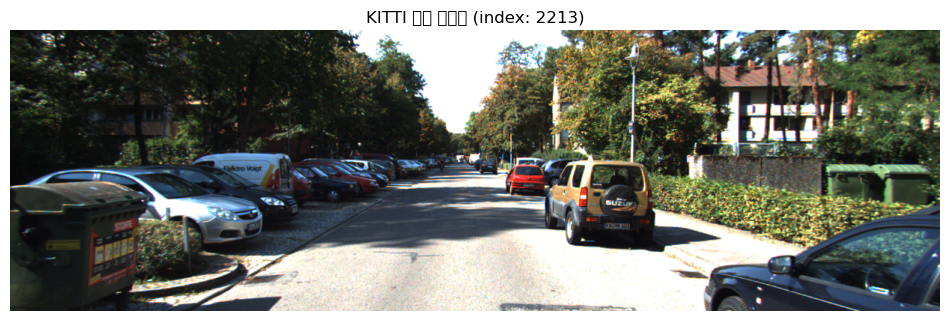


라벨 키: ['type', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y']

라벨 내용:
{'type': 'Car', 'truncated': 0.99, 'occluded': 0, 'alpha': -2.36, 'bbox': [928.32, 215.06, 1241.0, 374.0], 'dimensions': [1.36, 1.55, 3.87], 'location': [2.78, 1.61, 2.59], 'rotation_y': -1.6}
{'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': -1.83, 'bbox': [714.09, 168.57, 863.95, 286.66], 'dimensions': [1.62, 1.48, 3.36], 'location': [2.69, 1.59, 11.71], 'rotation_y': -1.61}
{'type': 'Car', 'truncated': 0.03, 'occluded': 3, 'alpha': 0.59, 'bbox': [0.0, 179.6, 345.44, 300.25], 'dimensions': [1.55, 1.7, 4.09], 'location': [-6.18, 1.67, 10.28], 'rotation_y': 0.06}
{'type': 'Car', 'truncated': 0.0, 'occluded': 2, 'alpha': 0.42, 'bbox': [138.8, 174.95, 391.66, 272.32], 'dimensions': [1.59, 1.63, 3.75], 'location': [-6.08, 1.66, 12.93], 'rotation_y': -0.01}
{'type': 'Car', 'truncated': 0.0, 'occluded': 2, 'alpha': -2.74, 'bbox': [191.98, 160.96, 384.51, 259.45], 'dimensions': [

In [3]:
# 데이터셋 샘플 하나를 무작위로 선택해 이미지와 라벨을 확인한다.
# bbox 좌표는 [x_min, y_min, x_max, y_max] 형식이다.

idx = random.randint(0, len(train_dataset) - 1)
sample = train_dataset[idx]

image = sample[0]
img_pil = TF.to_pil_image(image)

print(f'Image index: {idx}')
print(f'이미지 크기 (C, H, W): {np.shape(image)}')

plt.figure(figsize=(12, 5))
plt.imshow(img_pil)
plt.title(f'KITTI 샘플 이미지 (index: {idx})')
plt.axis('off')
plt.show()

objects = sample[1]
print('\n라벨 키:', list(objects[0].keys()) if objects else '없음')
print('\n라벨 내용:')
for obj in objects:
    print(obj)

---
## 2. 데이터 파이프라인 구축

데이터 파이프라인은 4단계로 이루어진다.
1. RandomHorizontalFlip: 좌우 무작위 뒤집기
2. ColorJitter: 색상 노이즈 추가
3. Resize: 이미지 크기 조정 (비율 유지, stride 배수로 패딩)
4. ToTensor + Normalize: 텐서 변환 및 정규화

In [4]:
# KITTI 클래스명을 인덱스로 매핑한다.
# 사람(Pedestrian)과 차량(Car)이 자율주행 보조 시스템의 핵심 탐지 대상이다.

KITTI_CLASSES = [
    'Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting',
    'Cyclist', 'Tram', 'Misc'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(KITTI_CLASSES)}
NUM_CLASSES = len(KITTI_CLASSES)

print('클래스 목록:', KITTI_CLASSES)
print('클래스-인덱스 매핑:', CLASS_TO_IDX)

클래스 목록: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
클래스-인덱스 매핑: {'Car': 0, 'Van': 1, 'Truck': 2, 'Pedestrian': 3, 'Person_sitting': 4, 'Cyclist': 5, 'Tram': 6, 'Misc': 7}


In [5]:
# 데이터 증강 함수들을 개별적으로 정의한다.
# 이미지와 bbox를 함께 변환해야 하므로 표준 transforms 대신 직접 구현한다.

def random_horizontal_flip(image, boxes, p=0.5):
    """
    이미지를 확률 p로 좌우 반전한다.
    bbox의 x 좌표도 이미지 너비 기준으로 반전시킨다.
    """
    if random.random() < p:
        image = TF.hflip(image)
        if boxes is not None and len(boxes) > 0:
            w = image.width
            # x_min, y_min, x_max, y_max -> 반전 후 x 좌표 재계산
            boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
    return image, boxes


def color_jitter(image, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
    """
    이미지의 밝기, 대비, 채도, 색조를 무작위로 변환한다.
    bbox는 영향을 받지 않으므로 그대로 반환한다.
    """
    jitter = transforms.ColorJitter(
        brightness=brightness,
        contrast=contrast,
        saturation=saturation,
        hue=hue
    )
    image = jitter(image)
    return image


print('증강 함수 정의 완료')

증강 함수 정의 완료


In [6]:
# 이미지 크기를 조정하는 함수를 정의한다.
# 이미지 비율을 유지하면서 크기를 바꾸고, stride의 배수가 되도록 패딩을 추가한다.
# 예: 600x720 이미지 -> 800x960으로 리사이즈 후 stride=128 기준 패딩 -> 896x1024

def resize_image_and_boxes(
    image,
    boxes,
    min_side=600,
    max_side=1024,
    min_side_range=(600, 800),
    stride=128,
    is_training=True
):
    """
    이미지 크기를 조정하고, stride 배수가 되도록 패딩을 추가한다.
    
    Args:
        image: PIL 이미지
        boxes: [N, 4] 형태의 bbox 텐서 (x_min, y_min, x_max, y_max)
        min_side: 짧은 변의 목표 크기
        max_side: 긴 변의 최대 크기
        min_side_range: 학습 시 min_side를 무작위로 선택할 범위
        stride: 패딩 단위 (FPN stride에 맞춤)
        is_training: True이면 min_side를 범위에서 무작위 선택
    """
    w, h = image.size

    # 학습 시: min_side를 범위 내에서 무작위 선택
    if is_training:
        min_side = random.randint(min_side_range[0], min_side_range[1])

    # 비율을 유지하면서 스케일 계산
    scale = min_side / min(h, w)
    new_h, new_w = int(round(h * scale)), int(round(w * scale))

    # 긴 변이 max_side를 초과하지 않도록 스케일 재조정
    if max(new_h, new_w) > max_side:
        scale = max_side / max(new_h, new_w)
        new_h, new_w = int(round(h * scale)), int(round(w * scale))

    image = image.resize((new_w, new_h), Image.BILINEAR)

    # stride 배수로 올림 패딩 계산
    pad_h = (stride - new_h % stride) % stride
    pad_w = (stride - new_w % stride) % stride

    # 검정(0) 패딩 추가 (오른쪽, 아래쪽)
    padded_image = Image.new('RGB', (new_w + pad_w, new_h + pad_h), (0, 0, 0))
    padded_image.paste(image, (0, 0))

    # bbox 좌표도 같은 스케일로 변환
    if boxes is not None and len(boxes) > 0:
        boxes = boxes * scale

    return padded_image, boxes, scale


print('Resize 함수 정의 완료')

Resize 함수 정의 완료


In [7]:
# 이미지를 텐서로 변환하고 ImageNet 기준으로 정규화한다.
# 정규화는 사전 학습된 ResNet50 백본 사용을 위해 필요하다.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def to_tensor_and_normalize(image):
    """
    PIL 이미지를 텐서로 변환하고 ImageNet 평균/표준편차로 정규화한다.
    """
    image = TF.to_tensor(image)        # [0, 1] 범위 텐서로 변환
    image = TF.normalize(image, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    return image


print('정규화 함수 정의 완료')

정규화 함수 정의 완료


In [8]:
# 위에서 정의한 변환 함수들을 하나의 파이프라인으로 연결한 Dataset 클래스를 작성한다.
# 학습/추론 모드를 구분해 증강 적용 여부를 결정한다.

class KITTIDetectionDataset(Dataset):
    """
    KITTI 데이터셋을 RetinaNet 학습에 맞는 형태로 변환하는 Dataset 클래스.
    
    반환 형태:
        image_tensor: [3, H, W] 정규화된 이미지 텐서
        boxes:        [N, 4] bbox 텐서 (x_min, y_min, x_max, y_max)
        labels:       [N] 클래스 인덱스 텐서
    """

    IGNORE_CLASSES = {'DontCare'}  # 학습에서 제외할 클래스

    def __init__(self, kitti_dataset, is_training=True,
                 min_side=600, max_side=1024,
                 min_side_range=(600, 800), stride=128):
        self.dataset      = kitti_dataset
        self.is_training  = is_training
        self.min_side     = min_side
        self.max_side     = max_side
        self.min_side_range = min_side_range
        self.stride       = stride

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_tensor, targets = self.dataset[idx]
        image = TF.to_pil_image(img_tensor)  # PIL 이미지로 변환

        # targets가 None인 경우 빈 리스트로 처리
        if targets is None:
            targets = []

        # bbox와 라벨 추출 (DontCare 클래스 제외)
        boxes_list, labels_list = [], []
        for obj in targets:
            cls_name = obj['type']
            if cls_name in self.IGNORE_CLASSES:
                continue
            if cls_name not in CLASS_TO_IDX:
                continue
            x1, y1, x2, y2 = obj['bbox']
            # 유효하지 않은 bbox 제외
            if x2 <= x1 or y2 <= y1:
                continue
            boxes_list.append([x1, y1, x2, y2])
            labels_list.append(CLASS_TO_IDX[cls_name])

        # bbox가 없는 경우 빈 텐서 반환
        if len(boxes_list) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.long)
        else:
            boxes  = torch.tensor(boxes_list,  dtype=torch.float32)
            labels = torch.tensor(labels_list, dtype=torch.long)

        # 학습 시 좌우 반전 증강 적용
        if self.is_training:
            image, boxes = random_horizontal_flip(image, boxes)
            image = color_jitter(image)

        # 이미지 크기 조정 및 패딩
        image, boxes, _ = resize_image_and_boxes(
            image, boxes,
            min_side=self.min_side,
            max_side=self.max_side,
            min_side_range=self.min_side_range,
            stride=self.stride,
            is_training=self.is_training
        )

        # 텐서 변환 및 정규화
        image = to_tensor_and_normalize(image)

        return image, boxes, labels


print('KITTIDetectionDataset 정의 완료')

KITTIDetectionDataset 정의 완료


In [9]:
# 배치 내 이미지 크기가 다를 수 있으므로, 같은 크기로 패딩해주는 collate 함수를 정의한다.
# DataLoader의 collate_fn으로 사용한다.

def collate_fn(batch):
    """
    배치 내 이미지를 가장 큰 크기에 맞춰 패딩한다.
    boxes와 labels는 리스트로 반환한다 (이미지마다 객체 수가 다르기 때문).
    """
    images, boxes_list, labels_list = zip(*batch)

    # 배치 내 최대 H, W 계산
    max_h = max(img.shape[1] for img in images)
    max_w = max(img.shape[2] for img in images)

    # 모든 이미지를 최대 크기로 0 패딩
    padded_images = torch.zeros(len(images), 3, max_h, max_w)
    for i, img in enumerate(images):
        _, h, w = img.shape
        padded_images[i, :, :h, :w] = img

    return padded_images, list(boxes_list), list(labels_list)


print('collate_fn 정의 완료')

collate_fn 정의 완료


In [10]:
# Dataset과 DataLoader를 생성한다.
# 배치 크기는 GPU 메모리에 따라 조정한다 (기본값 2).

train_kitti = KITTIDetectionDataset(train_dataset, is_training=True)
val_kitti   = KITTIDetectionDataset(test_dataset,  is_training=False)

train_loader = DataLoader(
    train_kitti,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True
)

val_loader = DataLoader(
    val_kitti,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True
)

print(f'Train 배치 수: {len(train_loader)}')
print(f'Val   배치 수: {len(val_loader)}')

Train 배치 수: 3741
Val   배치 수: 3759


---
## 3. Anchor 생성 및 LabelEncoder

One-stage detector는 미리 정의된 Anchor Box를 기반으로 물체를 탐지한다.
RetinaNet에서는 FPN의 각 pyramid level(P3~P7)마다 Anchor Box가 생성된다.

In [11]:
# RetinaNet 논문과 동일한 방식으로 Anchor Box를 생성하는 클래스를 정의한다.
# 각 FPN level(P3~P7)에서 3가지 비율(ratios)과 3가지 스케일(scales)을 조합해 9개의 Anchor를 생성한다.

class AnchorGenerator:
    """
    FPN pyramid level별 Anchor Box를 생성한다.
    
    논문 설정:
        - 각 level의 base size: 32, 64, 128, 256, 512
        - aspect ratios: 0.5, 1.0, 2.0
        - scales: 2^0, 2^(1/3), 2^(2/3)
        -> 각 level당 9개 anchor, 총 P3~P7 = 5 levels
    """

    def __init__(
        self,
        pyramid_levels=(3, 4, 5, 6, 7),
        strides=(8, 16, 32, 64, 128),
        sizes=(32, 64, 128, 256, 512),
        ratios=(0.5, 1.0, 2.0),
        scales=(1.0, 2**(1/3), 2**(2/3))
    ):
        self.pyramid_levels = pyramid_levels
        self.strides = strides
        self.sizes   = sizes
        self.ratios  = ratios
        self.scales  = scales

    def generate(self, image_shape):
        """
        이미지 크기에 맞는 Anchor를 모든 pyramid level에서 생성해 이어 붙인다.
        
        Args:
            image_shape: (H, W) 입력 이미지 크기
        Returns:
            anchors: [총 anchor 수, 4] 텐서 (x_min, y_min, x_max, y_max)
        """
        all_anchors = []
        for level_idx, (stride, size) in enumerate(zip(self.strides, self.sizes)):
            h = int(np.ceil(image_shape[0] / stride))
            w = int(np.ceil(image_shape[1] / stride))
            anchors = self._generate_level_anchors(h, w, stride, size)
            all_anchors.append(anchors)
        return torch.cat(all_anchors, dim=0)

    def _generate_level_anchors(self, feat_h, feat_w, stride, base_size):
        """
        하나의 pyramid level에서 Anchor Box를 생성한다.
        
        각 feature map 셀 위치마다 ratios x scales = 9개의 anchor를 생성한다.
        """
        # 기준 anchor: 비율(ratio)과 스케일(scale)을 적용해 너비와 높이 계산
        base_anchors = []
        for ratio in self.ratios:
            for scale in self.scales:
                area  = (base_size * scale) ** 2
                w_a   = np.sqrt(area / ratio)
                h_a   = w_a * ratio
                # 중심 (0, 0) 기준 anchor 좌표
                base_anchors.append([
                    -w_a / 2, -h_a / 2,
                     w_a / 2,  h_a / 2
                ])
        base_anchors = np.array(base_anchors, dtype=np.float32)  # [9, 4]

        # feature map의 각 셀 중심 좌표 계산
        shift_x = (np.arange(feat_w) + 0.5) * stride
        shift_y = (np.arange(feat_h) + 0.5) * stride
        shift_x, shift_y = np.meshgrid(shift_x, shift_y)
        shifts = np.stack([
            shift_x.ravel(), shift_y.ravel(),
            shift_x.ravel(), shift_y.ravel()
        ], axis=1)  # [feat_h*feat_w, 4]

        # 각 셀 위치에 기준 anchor를 더해 최종 anchor 생성
        anchors = (shifts[:, None, :] + base_anchors[None, :, :]).reshape(-1, 4)
        return torch.tensor(anchors, dtype=torch.float32)


print('AnchorGenerator 정의 완료')

AnchorGenerator 정의 완료


In [12]:
# IoU(Intersection over Union) 계산 함수를 정의한다.
# Anchor Box와 Ground Truth bbox 사이의 겹침 정도를 [0, 1]로 나타낸다.
# IoU > 0.5: 물체로 할당, IoU < 0.4: 배경으로 할당, 그 사이: 무시

def compute_iou(boxes1, boxes2):
    """
    두 bbox 집합 사이의 IoU를 계산한다.
    
    Args:
        boxes1: [N, 4] 텐서 (x_min, y_min, x_max, y_max)
        boxes2: [M, 4] 텐서
    Returns:
        iou: [N, M] IoU 행렬
    """
    # 교집합 영역 계산: 좌상단은 최댓값, 우하단은 최솟값
    lu = torch.maximum(boxes1[:, None, :2], boxes2[:, :2])
    rd = torch.minimum(boxes1[:, None, 2:], boxes2[:, 2:])
    intersection = torch.clamp(rd - lu, min=0.0)
    intersection_area = intersection[:, :, 0] * intersection[:, :, 1]

    # 각 bbox의 넓이 계산
    boxes1_area = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    boxes2_area = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    # 합집합 = 넓이1 + 넓이2 - 교집합
    union_area = boxes1_area[:, None] + boxes2_area - intersection_area

    return intersection_area / torch.clamp(union_area, min=1e-8)


print('IoU 계산 함수 정의 완료')

IoU 계산 함수 정의 완료


In [13]:
# Ground Truth bbox를 Anchor Box 기준의 회귀 타깃으로 변환하는 LabelEncoder를 정의한다.
# 이 과정을 통해 주관식 정답(실제 bbox)을 객관식 형태(Anchor 기반 오프셋)로 인코딩한다.
#
# 인코딩 방식:
#   tx = (cx_gt - cx_a) / w_a / 0.1  (variance=0.1)
#   ty = (cy_gt - cy_a) / h_a / 0.1
#   tw = log(w_gt / w_a) / 0.2       (variance=0.2)
#   th = log(h_gt / h_a) / 0.2

class LabelEncoder:
    """
    Anchor Box를 기반으로 학습 타깃을 인코딩/디코딩한다.
    
    IoU 임계값:
        IoU >= 0.5: 물체 (positive)
        IoU <  0.4: 배경 (negative)
        그 사이:    무시 (ignore, -1)
    """

    def __init__(self, num_classes, pos_iou=0.5, neg_iou=0.4,
                 variance=(0.1, 0.2)):
        self.num_classes = num_classes
        self.pos_iou     = pos_iou
        self.neg_iou     = neg_iou
        self.variance    = variance  # (중심 좌표 분산, 크기 분산)

    def encode(self, anchors, boxes, labels):
        """
        Anchor에 대해 분류 타깃과 박스 회귀 타깃을 생성한다.
        
        Args:
            anchors: [A, 4] 전체 anchor 텐서
            boxes:   [N, 4] Ground Truth bbox
            labels:  [N]    GT 클래스 인덱스
        Returns:
            cls_targets: [A, num_classes] 분류 타깃 (-1=무시, 0=배경, 1=물체)
            box_targets: [A, 4]           박스 회귀 타깃
        """
        A = anchors.shape[0]

        # GT가 없는 경우 전부 배경으로 처리
        if boxes.shape[0] == 0:
            cls_targets = torch.zeros(A, self.num_classes)
            box_targets = torch.zeros(A, 4)
            return cls_targets, box_targets

        # IoU 계산 및 각 Anchor에 가장 잘 맞는 GT 찾기
        iou_matrix = compute_iou(anchors, boxes)   # [A, N]
        max_iou, max_idx = iou_matrix.max(dim=1)   # [A]

        # 분류 타깃 초기화 (-1: 무시)
        cls_targets = torch.full((A, self.num_classes), -1.0)

        # 배경 anchor (IoU < neg_iou): 모든 클래스 0
        neg_mask = max_iou < self.neg_iou
        cls_targets[neg_mask] = 0.0

        # 물체 anchor (IoU >= pos_iou): 해당 클래스 1, 나머지 0
        pos_mask = max_iou >= self.pos_iou
        pos_labels = labels[max_idx[pos_mask]]
        cls_targets[pos_mask] = 0.0
        cls_targets[pos_mask, pos_labels] = 1.0

        # 박스 회귀 타깃: Anchor와 GT의 오프셋을 variance로 나눠 스케일 조정
        matched_boxes = boxes[max_idx]  # [A, 4]

        # anchor와 matched GT를 중심-크기 형식으로 변환
        a_cx = (anchors[:, 0] + anchors[:, 2]) / 2
        a_cy = (anchors[:, 1] + anchors[:, 3]) / 2
        a_w  =  anchors[:, 2] - anchors[:, 0]
        a_h  =  anchors[:, 3] - anchors[:, 1]

        g_cx = (matched_boxes[:, 0] + matched_boxes[:, 2]) / 2
        g_cy = (matched_boxes[:, 1] + matched_boxes[:, 3]) / 2
        g_w  =  matched_boxes[:, 2] - matched_boxes[:, 0]
        g_h  =  matched_boxes[:, 3] - matched_boxes[:, 1]

        # 오프셋 인코딩
        tx = (g_cx - a_cx) / (a_w * self.variance[0])
        ty = (g_cy - a_cy) / (a_h * self.variance[0])
        tw = torch.log(g_w / a_w.clamp(min=1e-8)) / self.variance[1]
        th = torch.log(g_h / a_h.clamp(min=1e-8)) / self.variance[1]

        box_targets = torch.stack([tx, ty, tw, th], dim=1)  # [A, 4]

        return cls_targets, box_targets

    def decode(self, anchors, box_preds):
        """
        모델이 예측한 box 오프셋을 실제 좌표로 디코딩한다.
        """
        a_cx = (anchors[:, 0] + anchors[:, 2]) / 2
        a_cy = (anchors[:, 1] + anchors[:, 3]) / 2
        a_w  =  anchors[:, 2] - anchors[:, 0]
        a_h  =  anchors[:, 3] - anchors[:, 1]

        cx = box_preds[:, 0] * self.variance[0] * a_w + a_cx
        cy = box_preds[:, 1] * self.variance[0] * a_h + a_cy
        w  = torch.exp(box_preds[:, 2] * self.variance[1]) * a_w
        h  = torch.exp(box_preds[:, 3] * self.variance[1]) * a_h

        x_min = cx - w / 2
        y_min = cy - h / 2
        x_max = cx + w / 2
        y_max = cy + h / 2

        return torch.stack([x_min, y_min, x_max, y_max], dim=1)


# LabelEncoder 인스턴스 생성
label_encoder = LabelEncoder(num_classes=NUM_CLASSES)
print('LabelEncoder 정의 완료')

LabelEncoder 정의 완료


---
## 4. RetinaNet 모델 작성

RetinaNet 구조: Backbone(ResNet50) + FPN(P3~P7) + Classification Head + Box Regression Head

In [14]:
# FPN(Feature Pyramid Network)을 구현한다.
# backbone의 여러 레이어 출력을 가져와 top-down 방식으로 합산해 pyramid를 구성한다.
# P3(stride=8)부터 P7(stride=128)까지 5개의 pyramid level을 생성한다.

class FeaturePyramidNetwork(nn.Module):
    """
    ResNet50의 C3, C4, C5 feature map을 입력받아
    P3~P7 pyramid feature map을 생성한다.
    
    각 level의 채널 수는 256으로 통일된다.
    """

    def __init__(self, in_channels_list=(512, 1024, 2048), out_channels=256):
        super().__init__()
        self.out_channels = out_channels

        # 1x1 conv: 각 backbone level의 채널 수를 256으로 맞춘다
        self.lateral_c3 = nn.Conv2d(in_channels_list[0], out_channels, 1)
        self.lateral_c4 = nn.Conv2d(in_channels_list[1], out_channels, 1)
        self.lateral_c5 = nn.Conv2d(in_channels_list[2], out_channels, 1)

        # 3x3 conv: top-down 합산 후 smoothing
        self.smooth_p3 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.smooth_p4 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.smooth_p5 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        # P6: C5에서 stride=2 conv로 생성
        self.p6 = nn.Conv2d(in_channels_list[2], out_channels, 3, stride=2, padding=1)

        # P7: P6에서 ReLU + stride=2 conv로 생성
        self.p7 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)

    def forward(self, c3, c4, c5):
        # top-down pathway: 깊은 레이어의 feature를 업샘플링해 얕은 레이어와 더함
        lat5 = self.lateral_c5(c5)
        lat4 = self.lateral_c4(c4)
        lat3 = self.lateral_c3(c3)

        p5 = self.smooth_p5(lat5)
        p4 = self.smooth_p4(lat4 + F.interpolate(lat5, size=lat4.shape[-2:], mode='nearest'))
        p3 = self.smooth_p3(lat3 + F.interpolate(lat4 + F.interpolate(lat5, size=lat4.shape[-2:], mode='nearest'), size=lat3.shape[-2:], mode='nearest'))

        p6 = self.p6(c5)
        p7 = self.p7(F.relu(p6))

        return [p3, p4, p5, p6, p7]


print('FPN 정의 완료')

FPN 정의 완료


In [15]:
# Classification Head와 Box Regression Head를 위한 공통 구조를 만드는 함수를 정의한다.
# 두 head 모두 동일한 구조(4개의 3x3 conv + ReLU)를 공유하기 때문에 함수로 재사용한다.

def build_head(in_channels=256, num_convs=4):
    """
    Head의 공통 conv 레이어를 구성한다.
    
    Args:
        in_channels: 입력 채널 수 (FPN 출력과 동일한 256)
        num_convs:   반복할 3x3 conv 레이어 수 (논문 기본값 4)
    Returns:
        nn.Sequential: conv-relu를 num_convs번 반복하는 레이어
    """
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, in_channels, 3, padding=1))
        layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)


print('build_head 함수 정의 완료')

build_head 함수 정의 완료


In [16]:
# ResNet50 백본을 정의한다.
# FPN에서 사용할 중간 레이어(layer2=C3, layer3=C4, layer4=C5) 출력을 꺼낼 수 있도록 연결한다.

class ResNet50Backbone(nn.Module):
    """
    사전 학습된 ResNet50에서 FPN용 feature map을 추출한다.
    
    출력:
        c3: layer2 출력 (stride=8,  채널=512)
        c4: layer3 출력 (stride=16, 채널=1024)
        c5: layer4 출력 (stride=32, 채널=2048)
    """

    def __init__(self, pretrained=True):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)

        # 입력 처리 레이어 (conv1, bn1, relu, maxpool)
        self.layer0 = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool
        )
        self.layer1 = resnet.layer1  # C2 (stride=4)
        self.layer2 = resnet.layer2  # C3 (stride=8)
        self.layer3 = resnet.layer3  # C4 (stride=16)
        self.layer4 = resnet.layer4  # C5 (stride=32)

    def forward(self, x):
        x  = self.layer0(x)
        x  = self.layer1(x)
        c3 = self.layer2(x)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c3, c4, c5


print('ResNet50Backbone 정의 완료')

ResNet50Backbone 정의 완료


In [17]:
# RetinaNet 전체 모델을 조립한다.
# Backbone -> FPN -> Classification Head / Box Regression Head
#
# Classification Head 출력: [B, H*W*9, num_classes]  (Focal Loss 적용)
# Box Regression Head 출력: [B, H*W*9, 4]            (Smooth L1 Loss 적용)

class RetinaNet(nn.Module):
    """
    RetinaNet 모델.
    
    Args:
        num_classes: 탐지할 클래스 수 (KITTI: 8)
        num_anchors: 각 위치당 anchor 수 (ratios x scales = 3x3 = 9)
        fpn_channels: FPN 출력 채널 수 (논문 기본값 256)
    """

    def __init__(self, num_classes=NUM_CLASSES, num_anchors=9, fpn_channels=256):
        super().__init__()
        self.num_classes = num_classes

        # 백본 + FPN
        self.backbone = ResNet50Backbone(pretrained=True)
        self.fpn      = FeaturePyramidNetwork(
            in_channels_list=(512, 1024, 2048),
            out_channels=fpn_channels
        )

        # 분류 head: 공통 conv 4개 + 최종 분류 conv
        self.cls_head  = build_head(fpn_channels, num_convs=4)
        self.cls_pred  = nn.Conv2d(fpn_channels, num_anchors * num_classes, 3, padding=1)

        # 박스 회귀 head: 공통 conv 4개 + 최종 회귀 conv
        self.box_head  = build_head(fpn_channels, num_convs=4)
        self.box_pred  = nn.Conv2d(fpn_channels, num_anchors * 4, 3, padding=1)

        # 가중치 초기화
        self._init_weights()

    def _init_weights(self):
        # 분류 head 마지막 레이어: 초기 예측이 배경 확률 0.99가 되도록 편향 초기화
        # 이를 통해 학습 초반 클래스 불균형으로 인한 불안정을 방지한다
        pi = 0.01
        nn.init.constant_(self.cls_pred.bias, -np.log((1 - pi) / pi))
        nn.init.normal_(self.cls_pred.weight, std=0.01)
        nn.init.normal_(self.box_pred.weight, std=0.01)
        nn.init.zeros_(self.box_pred.bias)

    def forward(self, x):
        # backbone에서 feature map 추출
        c3, c4, c5 = self.backbone(x)

        # FPN으로 pyramid feature map 생성
        fpn_features = self.fpn(c3, c4, c5)  # [p3, p4, p5, p6, p7]

        cls_outputs = []
        box_outputs = []

        for feat in fpn_features:
            # 분류 예측
            cls_out = self.cls_pred(self.cls_head(feat))
            # [B, num_anchors*num_classes, H, W] -> [B, H*W*num_anchors, num_classes]
            B, _, H, W = cls_out.shape
            cls_out = cls_out.view(B, -1, self.num_classes, H, W)
            cls_out = cls_out.permute(0, 3, 4, 1, 2).contiguous()
            cls_out = cls_out.view(B, -1, self.num_classes)
            cls_outputs.append(cls_out)

            # 박스 회귀 예측
            box_out = self.box_pred(self.box_head(feat))
            # [B, num_anchors*4, H, W] -> [B, H*W*num_anchors, 4]
            box_out = box_out.view(B, -1, 4, H, W)
            box_out = box_out.permute(0, 3, 4, 1, 2).contiguous()
            box_out = box_out.view(B, -1, 4)
            box_outputs.append(box_out)

        # 모든 pyramid level 결과를 이어 붙임
        cls_outputs = torch.cat(cls_outputs, dim=1)  # [B, 총 anchor 수, num_classes]
        box_outputs = torch.cat(box_outputs, dim=1)  # [B, 총 anchor 수, 4]

        return cls_outputs, box_outputs


print('RetinaNet 정의 완료')

RetinaNet 정의 완료


---
## 5. Focal Loss + Smooth L1 Loss 정의

- **Focal Loss**: 클래스 불균형 문제를 해결하기 위해 쉬운 샘플의 손실을 줄인다.
- **Smooth L1 Loss**: bbox 회귀에 사용하며, 아웃라이어에 강건하다.

In [18]:
# Focal Loss를 구현한다.
# FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
#
# alpha: 물체/배경 가중치 조절 (기본값 0.25)
# gamma: 쉬운 샘플의 손실을 줄이는 modulating factor (기본값 2.0)
#        gamma=0이면 일반적인 Cross Entropy와 동일하다.

class FocalLoss(nn.Module):

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):
        """
        Args:
            preds:   [A, num_classes] 분류 예측값 (logits)
            targets: [A, num_classes] 분류 타깃 (-1: 무시, 0: 배경, 1: 물체)
        Returns:
            scalar loss
        """
        # 무시(-1) 위치는 손실 계산에서 제외
        valid_mask = targets >= 0
        p     = torch.sigmoid(preds)
        p_t   = p * targets + (1 - p) * (1 - targets)

        # alpha 가중치: 물체=alpha, 배경=1-alpha
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # modulating factor: 쉬운 샘플일수록 (p_t가 높을수록) 손실을 줄임
        focal_weight = (1 - p_t) ** self.gamma

        # Binary Cross Entropy
        bce = F.binary_cross_entropy_with_logits(
            preds, targets.float(), reduction='none'
        )

        loss = alpha_t * focal_weight * bce

        # 무시 위치 제외 후 평균 계산 (positive anchor 수로 정규화)
        loss = loss[valid_mask].sum()
        num_pos = (targets == 1).sum().clamp(min=1.0)
        return loss / num_pos


print('FocalLoss 정의 완료')

FocalLoss 정의 완료


In [19]:
# Smooth L1 Loss를 구현한다.
# delta 기준으로 두 가지 수식을 적용한다.
#   |x| <= delta: 0.5 * x^2 / delta  (이차 함수, 안정적)
#   |x| >  delta: |x| - 0.5 * delta  (선형 함수, 아웃라이어 강건)

class SmoothL1Loss(nn.Module):

    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, preds, targets, pos_mask):
        """
        물체로 할당된 anchor(positive)에 대해서만 손실을 계산한다.
        
        Args:
            preds:    [A, 4] 예측 박스 오프셋
            targets:  [A, 4] 타깃 박스 오프셋
            pos_mask: [A]    positive anchor 마스크
        Returns:
            scalar loss
        """
        if pos_mask.sum() == 0:
            return torch.tensor(0.0, device=preds.device)

        preds_pos   = preds[pos_mask]
        targets_pos = targets[pos_mask]

        diff = torch.abs(preds_pos - targets_pos)
        loss = torch.where(
            diff <= self.delta,
            0.5 * diff ** 2 / self.delta,
            diff - 0.5 * self.delta
        )
        return loss.mean()


# 손실 함수 인스턴스 생성
focal_loss_fn  = FocalLoss(alpha=0.25, gamma=2.0)
smooth_l1_fn   = SmoothL1Loss(delta=1.0)

print('손실 함수 정의 완료')

손실 함수 정의 완료


---
## 6. 모델 학습

In [20]:
# 학습에 사용할 하이퍼파라미터와 경로를 설정한다.

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS      = 10
LR          = 1e-4
CHECKPOINT_DIR = os.path.join(os.getenv('HOME'), 'work/object_detection/checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'학습 장치: {DEVICE}')
print(f'에포크 수: {EPOCHS}')
print(f'학습률: {LR}')
print(f'체크포인트 저장 경로: {CHECKPOINT_DIR}')

학습 장치: cuda
에포크 수: 10
학습률: 0.0001
체크포인트 저장 경로: /home/jovyan/work/object_detection/checkpoints


In [21]:
# 모델, 옵티마이저, 스케줄러를 설정한다.
# Adam 옵티마이저와 ReduceLROnPlateau 스케줄러를 사용한다.
# 논문에서는 SGD를 사용했지만, 단일 GPU 환경에서는 Adam이 더 빠르게 수렴한다.

model     = RetinaNet(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# val_loss가 patience 에포크 동안 개선되지 않으면 lr을 factor배 감소
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

anchor_gen = AnchorGenerator()

print('모델 구성 완료')
print(f'총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}')

모델 구성 완료
총 파라미터 수: 36,475,052


In [22]:
# 체크포인트 저장 및 불러오기 유틸리티 함수를 정의한다.

def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        'epoch':      epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss':   val_loss
    }, path)


def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return checkpoint['epoch'], checkpoint['val_loss']


print('체크포인트 유틸리티 정의 완료')

체크포인트 유틸리티 정의 완료


In [23]:
# 1 에포크 학습을 수행하는 함수를 정의한다.
# 각 배치에서 anchor 생성, LabelEncoder 적용, 손실 계산, 역전파를 수행한다.

def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_anchors = 0

    pbar = tqdm(loader, desc=f'Train Epoch {epoch+1}', leave=False)
    for images, boxes_list, labels_list in pbar:
        images = images.to(device)
        optimizer.zero_grad()

        # 순전파
        cls_preds, box_preds = model(images)  # [B, A, C], [B, A, 4]

        B, A, C = cls_preds.shape
        _, H, W = images.shape[1], images.shape[2], images.shape[3]

        # 이미지 크기에 맞는 anchor 생성
        anchors = anchor_gen.generate((H, W)).to(device)  # [A, 4]

        batch_cls_loss = 0.0
        batch_box_loss = 0.0

        for i in range(B):
            boxes  = boxes_list[i].to(device)
            labels = labels_list[i].to(device)

            # anchor별 분류/박스 타깃 생성
            cls_targets, box_targets = label_encoder.encode(anchors, boxes, labels)

            # Focal Loss (분류)
            cls_loss = focal_loss_fn(cls_preds[i], cls_targets.to(device))

            # Smooth L1 Loss (박스 회귀, positive anchor만)
            pos_mask = (cls_targets.max(dim=1).values == 1)
            box_loss = smooth_l1_fn(
                box_preds[i], box_targets.to(device), pos_mask
            )

            batch_cls_loss += cls_loss
            batch_box_loss += box_loss

            # 분류 정확도 계산 (positive anchor 중 클래스를 맞힌 비율)
            if pos_mask.sum() > 0:
                pred_cls = cls_preds[i][pos_mask].argmax(dim=1)
                true_cls = cls_targets[pos_mask].argmax(dim=1).to(device)
                total_correct += (pred_cls == true_cls).sum().item()
                total_anchors += pos_mask.sum().item()

        # 배치 손실 합산 및 역전파
        loss = (batch_cls_loss + batch_box_loss) / B
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    acc      = (total_correct / total_anchors * 100) if total_anchors > 0 else 0.0
    return avg_loss, acc


print('train_one_epoch 함수 정의 완료')

train_one_epoch 함수 정의 완료


In [24]:
# 검증(validation) 함수를 정의한다.
# 역전파 없이 손실과 정확도만 계산한다.

def validate(model, loader, device, epoch):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_anchors = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc=f'Val   Epoch {epoch+1}', leave=False)
        for images, boxes_list, labels_list in pbar:
            images = images.to(device)
            cls_preds, box_preds = model(images)

            _, H, W = images.shape[1], images.shape[2], images.shape[3]
            anchors = anchor_gen.generate((H, W)).to(device)

            B = images.shape[0]
            batch_cls_loss = 0.0
            batch_box_loss = 0.0

            for i in range(B):
                boxes  = boxes_list[i].to(device)
                labels = labels_list[i].to(device)

                cls_targets, box_targets = label_encoder.encode(anchors, boxes, labels)

                cls_loss = focal_loss_fn(cls_preds[i], cls_targets.to(device))
                pos_mask = (cls_targets.max(dim=1).values == 1)
                box_loss = smooth_l1_fn(box_preds[i], box_targets.to(device), pos_mask)

                batch_cls_loss += cls_loss
                batch_box_loss += box_loss

                if pos_mask.sum() > 0:
                    pred_cls = cls_preds[i][pos_mask].argmax(dim=1)
                    true_cls = cls_targets[pos_mask].argmax(dim=1).to(device)
                    total_correct += (pred_cls == true_cls).sum().item()
                    total_anchors += pos_mask.sum().item()

            loss = (batch_cls_loss + batch_box_loss) / B
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    acc      = (total_correct / total_anchors * 100) if total_anchors > 0 else 0.0
    return avg_loss, acc


print('validate 함수 정의 완료')

validate 함수 정의 완료


In [25]:
# 학습 루프를 실행한다.
# 각 에포크마다 학습 및 검증을 수행하고, val_loss 기준으로 최적 모델을 저장한다.
#
# 참고: epoch 1회당 수십 분 이상 소요될 수 있다.
# 빠른 확인이 필요하면 EPOCHS=1로 설정하거나 아래 '결과 확인' 단계에서
# 미리 학습된 가중치를 불러와 사용한다.

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
start_epoch   = 0

# 이전 체크포인트가 있으면 이어서 학습
last_ckpt = os.path.join(CHECKPOINT_DIR, 'last.pth')
if os.path.exists(last_ckpt):
    start_epoch, best_val_loss = load_checkpoint(model, optimizer, last_ckpt)
    start_epoch += 1
    print(f'체크포인트 불러옴 (epoch {start_epoch}부터 재개)')

print('=' * 60)
print(f'학습 장치: {DEVICE}')
print(f'총 에포크: {EPOCHS}')
print('=' * 60)

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, DEVICE, epoch)
    val_loss,   val_acc   = validate(model, val_loader, DEVICE, epoch)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f'Epoch [{epoch+1}/{EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | '
          f'Time: {elapsed:.1f}s')

    # 마지막 체크포인트 저장
    save_checkpoint(model, optimizer, epoch, val_loss,
                    os.path.join(CHECKPOINT_DIR, 'last.pth'))

    # 최적 모델 저장 (val_loss 기준)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss,
                        os.path.join(CHECKPOINT_DIR, 'best.pth'))
        print(f'  >> 최적 모델 저장 (val_loss: {val_loss:.4f})')

    print('-' * 60)

print('학습 완료')

학습 장치: cuda
총 에포크: 10


Epoch [1/10] Train Loss: 0.5954 | Train Acc: 78.34% | Val Loss: 17.3283 | Val Acc: 0.00% | Time: 744.5s
  >> 최적 모델 저장 (val_loss: 17.3283)
------------------------------------------------------------


Epoch [2/10] Train Loss: 0.3549 | Train Acc: 83.58% | Val Loss: 35.2942 | Val Acc: 0.00% | Time: 736.9s
------------------------------------------------------------


Epoch [3/10] Train Loss: 0.3039 | Train Acc: 85.71% | Val Loss: 28.9651 | Val Acc: 0.00% | Time: 737.9s
------------------------------------------------------------


Epoch [4/10] Train Loss: 0.2702 | Train Acc: 87.10% | Val Loss: 39.2534 | Val Acc: 0.00% | Time: 735.5s
------------------------------------------------------------


...

Epoch [6/10] Train Loss: 0.1884 | Train Acc: 91.15% | Val Loss: 59.9432 | Val Acc: 0.00% | Time: 733.1s
------------------------------------------------------------


Epoch [7/10] Train Loss: 0.1790 | Train Acc: 92.26% | Val Loss: 71.1425 | Val Acc: 0.00% | Time: 733.6s
------------------------------------------------------------


Epoch [8/10] Train Loss: 0.1480 | Train Acc: 94.14% | Val Loss: 81.9321 | Val Acc: 0.00% | Time: 734.8s
------------------------------------------------------------


Epoch [9/10] Train Loss: 0.1408 | Train Acc: 94.87% | Val Loss: 77.6381 | Val Acc: 0.00% | Time: 735.2s
------------------------------------------------------------


Epoch [10/10] Train Loss: 0.1339 | Train Acc: 95.32% | Val Loss: 80.7964 | Val Acc: 0.00% | Time: 732.7s
------------------------------------------------------------
학습 완료


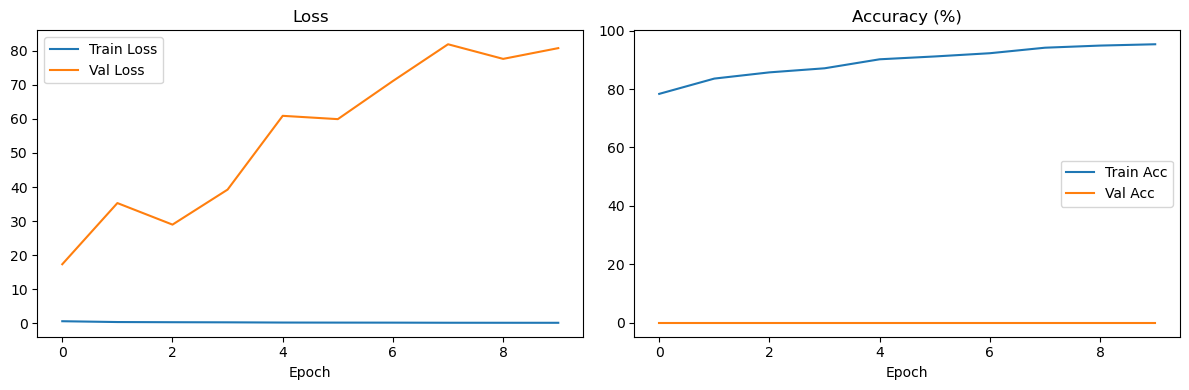

In [26]:
# 학습 손실/정확도 그래프를 그린다.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_history.png'), dpi=100)
plt.show()

---
## 7. 결과 확인

학습된(또는 미리 학습된) 모델을 불러와 추론 결과를 시각화한다.

In [27]:
# 추론용 후처리 모듈을 정의한다.
# 논문 설정: 신뢰도 0.05 이상의 box 중 상위 100개를 선택 후 NMS 적용 (임계값 0.5)

class PostProcess(nn.Module):
    """
    모델 출력(cls_preds, box_preds)에서 최종 탐지 결과를 생성한다.
    
    과정:
        1. sigmoid로 분류 확률 계산
        2. 신뢰도 임계값(score_thresh) 이상인 box 필터링
        3. 상위 top_k개 선택
        4. LabelEncoder.decode로 실제 좌표로 변환
        5. NMS(Non-Maximum Suppression) 적용
    """

    def __init__(self, num_classes, score_thresh=0.05, nms_thresh=0.5, top_k=100):
        super().__init__()
        self.num_classes  = num_classes
        self.score_thresh = score_thresh
        self.nms_thresh   = nms_thresh
        self.top_k        = top_k
        self.decoder      = LabelEncoder(num_classes)

    def forward(self, cls_preds, box_preds, anchors, image_shape):
        """
        단일 이미지에 대해 최종 탐지 결과를 반환한다.
        
        Returns:
            boxes:  [K, 4] 탐지된 bbox
            scores: [K]    신뢰도 점수
            labels: [K]    클래스 인덱스
        """
        scores_all = torch.sigmoid(cls_preds)    # [A, C]
        scores, class_ids = scores_all.max(dim=1)  # [A]

        # 신뢰도 임계값 필터링
        keep = scores > self.score_thresh
        scores    = scores[keep]
        class_ids = class_ids[keep]
        box_preds = box_preds[keep]
        anchors_f = anchors[keep]

        # box 좌표 디코딩
        boxes = self.decoder.decode(anchors_f, box_preds)

        # 이미지 경계 클리핑
        H, W = image_shape
        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, W)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, H)

        # 상위 top_k 선택
        if len(scores) > self.top_k:
            topk_idx = scores.topk(self.top_k).indices
            scores    = scores[topk_idx]
            class_ids = class_ids[topk_idx]
            boxes     = boxes[topk_idx]

        # 클래스별 NMS 적용
        keep_idx = nms(boxes, scores, self.nms_thresh)

        return boxes[keep_idx], scores[keep_idx], class_ids[keep_idx]


post_process = PostProcess(num_classes=NUM_CLASSES)
print('PostProcess 정의 완료')

PostProcess 정의 완료


In [28]:
# 추론 전처리 함수를 정의한다.
# 학습 전처리와 달리 증강 없이 크기 조정과 정규화만 수행한다.

def preprocess_for_inference(image_path, min_side=600, max_side=1024, stride=128):
    """
    추론용 이미지를 전처리한다.
    
    Args:
        image_path: 이미지 파일 경로
    Returns:
        img_tensor: [1, 3, H, W] 정규화된 입력 텐서
        original:   원본 PIL 이미지
        scale:      리사이즈 스케일 (bbox 좌표 역변환에 사용)
    """
    original = Image.open(image_path).convert('RGB')
    image, _, scale = resize_image_and_boxes(
        original, None,
        min_side=min_side, max_side=max_side,
        stride=stride, is_training=False
    )
    img_tensor = to_tensor_and_normalize(image).unsqueeze(0)
    return img_tensor, original, scale


print('추론 전처리 함수 정의 완료')

추론 전처리 함수 정의 완료


In [29]:
# 탐지 결과를 이미지에 시각화하는 함수를 정의한다.
# 각 bbox 위에 클래스명과 신뢰도 점수를 표시한다.

COLORS = plt.cm.get_cmap('tab10', NUM_CLASSES)

def visualize_detections(image, boxes, scores, class_ids, scale=1.0,
                          score_thresh=0.3, title='Detection Result'):
    """
    탐지 결과를 이미지에 오버레이해 시각화한다.
    
    Args:
        image:    원본 PIL 이미지
        boxes:    [K, 4] 탐지된 bbox (전처리 스케일 기준)
        scores:   [K]    신뢰도 점수
        class_ids:[K]    클래스 인덱스
        scale:    전처리 스케일 (원본 좌표 복원)
    """
    fig, ax = plt.subplots(1, figsize=(14, 7))
    ax.imshow(image)

    for box, score, cls_id in zip(boxes, scores, class_ids):
        if score < score_thresh:
            continue

        # 원본 이미지 좌표로 복원
        x1, y1, x2, y2 = (box / scale).tolist()
        w_box = x2 - x1
        h_box = y2 - y1

        color = COLORS(cls_id.item())
        rect  = patches.Rectangle(
            (x1, y1), w_box, h_box,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        label_text = f'{KITTI_CLASSES[cls_id]}: {score:.2f}'
        ax.text(
            x1, y1 - 5, label_text,
            fontsize=9, color='white',
            bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none')
        )

    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


print('시각화 함수 정의 완료')

시각화 함수 정의 완료


/tmp/ipykernel_629/1920522900.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap('tab10', NUM_CLASSES)


최적 모델 불러옴
탐지된 객체 수: 2


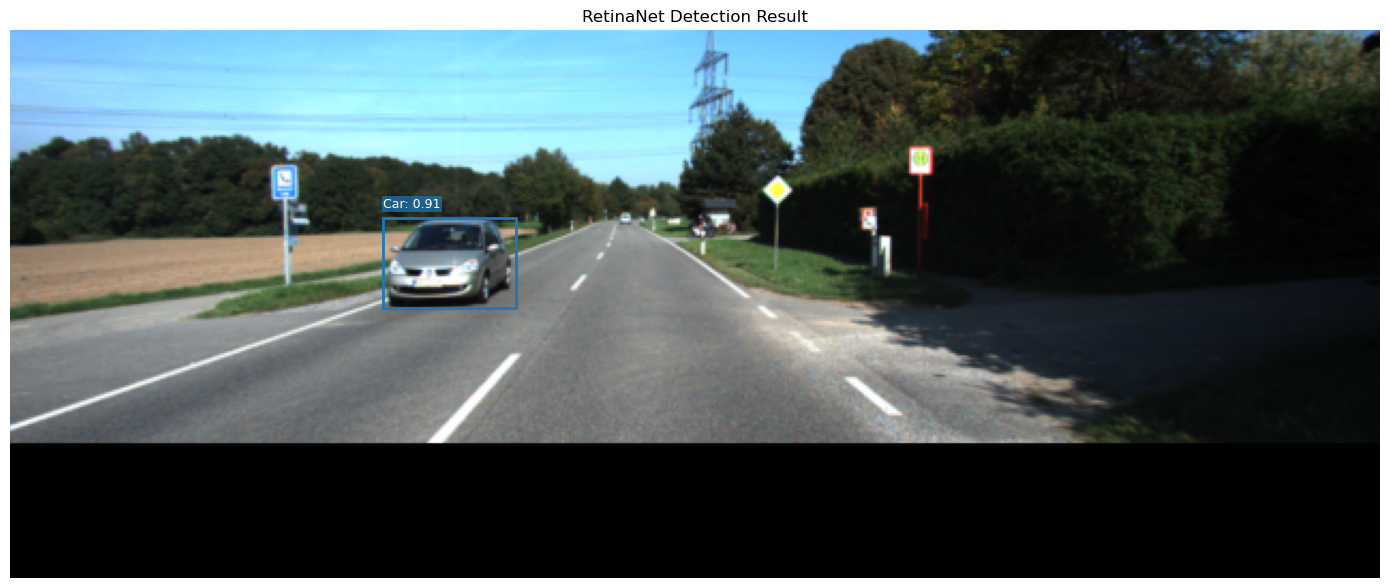

In [30]:
# 학습된 모델을 불러와 테스트 샘플에 대해 탐지 결과를 확인한다.
# best.pth가 없으면 현재 학습된 모델 상태를 사용한다.

best_ckpt = os.path.join(CHECKPOINT_DIR, 'best.pth')
if os.path.exists(best_ckpt):
    load_checkpoint(model, None, best_ckpt)
    print('최적 모델 불러옴')
else:
    print('체크포인트 없음 - 현재 모델 상태 사용')

model.eval()

# 테스트 데이터셋에서 샘플 이미지를 추론
sample_image, sample_boxes, sample_labels = val_kitti[0]

with torch.no_grad():
    img_input = sample_image.unsqueeze(0).to(DEVICE)  # [1, 3, H, W]
    cls_preds, box_preds = model(img_input)

    H, W = img_input.shape[2], img_input.shape[3]
    anchors = anchor_gen.generate((H, W)).to(DEVICE)

    boxes, scores, class_ids = post_process(
        cls_preds[0], box_preds[0], anchors, (H, W)
    )

print(f'탐지된 객체 수: {len(boxes)}')

# 원본 이미지로 복원해 시각화
orig_img = TF.to_pil_image(sample_image * torch.tensor(IMAGENET_STD).view(3,1,1)
                            + torch.tensor(IMAGENET_MEAN).view(3,1,1))

visualize_detections(
    orig_img, boxes.cpu(), scores.cpu(), class_ids.cpu(),
    scale=1.0, title='RetinaNet Detection Result'
)

---
## 8. 프로젝트: 자율주행 보조 시스템

### 정지 조건
1. 사람(Pedestrian)이 한 명 이상 탐지된 경우
2. 차량(Car)의 width 또는 height가 300px 이상인 경우

두 조건 중 하나라도 만족하면 **Stop**, 아니면 **Go**를 반환한다.

In [31]:
# 자율주행 보조 함수를 정의한다.
# 입력으로 이미지 경로를 받아 탐지 결과를 분석하고 'Stop' 또는 'Go'를 반환한다.

# 탐지 대상 클래스 인덱스
PEDESTRIAN_IDX = CLASS_TO_IDX['Pedestrian']  # 사람
CAR_IDX        = CLASS_TO_IDX['Car']          # 차량
SIZE_LIMIT     = 300                           # 차량 크기(px) 임계값
SCORE_THRESH   = 0.3                           # 탐지 신뢰도 임계값


def self_drive_assist(img_path, size_limit=SIZE_LIMIT):
    """
    이미지를 분석해 자율주행 보조 판단을 반환한다.
    
    정지 조건:
        - 사람(Pedestrian)이 1명 이상 탐지된 경우
        - 차량(Car)의 width 또는 height가 size_limit(px) 이상인 경우
    
    Args:
        img_path:   입력 이미지 경로 (str)
        size_limit: 차량 크기 임계값 (기본값 300px)
    Returns:
        'Stop' 또는 'Go' (str)
    """
    # 이미지 전처리
    img_tensor, original, scale = preprocess_for_inference(img_path)
    img_tensor = img_tensor.to(DEVICE)

    # 모델 추론
    model.eval()
    with torch.no_grad():
        cls_preds, box_preds = model(img_tensor)
        H, W = img_tensor.shape[2], img_tensor.shape[3]
        anchors = anchor_gen.generate((H, W)).to(DEVICE)
        boxes, scores, class_ids = post_process(
            cls_preds[0], box_preds[0], anchors, (H, W)
        )

    # 신뢰도 임계값 이상만 사용
    keep = scores >= SCORE_THRESH
    boxes      = boxes[keep]
    class_ids  = class_ids[keep]

    # 원본 이미지 좌표로 복원
    boxes_orig = boxes.cpu() / scale

    # 조건 1: 사람이 한 명 이상 탐지되면 Stop
    person_detected = (class_ids == PEDESTRIAN_IDX).any().item()
    if person_detected:
        return 'Stop'

    # 조건 2: 차량 bbox의 width 또는 height가 size_limit 이상이면 Stop
    car_mask = (class_ids == CAR_IDX)
    if car_mask.any():
        car_boxes = boxes_orig[car_mask.cpu()]
        widths  = car_boxes[:, 2] - car_boxes[:, 0]
        heights = car_boxes[:, 3] - car_boxes[:, 1]
        if (widths >= size_limit).any() or (heights >= size_limit).any():
            return 'Stop'

    return 'Go'


# 간단한 동작 확인
DATA_PATH = os.path.join(os.getenv('HOME'), 'work/object_detection/data')
test_img  = os.path.join(DATA_PATH, 'stop_1.png')

if os.path.exists(test_img):
    result = self_drive_assist(test_img)
    print(f'테스트 결과: {result}')
else:
    print('테스트 이미지가 없습니다. 경로를 확인해주세요.')

print('self_drive_assist 함수 정의 완료')

테스트 결과: Stop
self_drive_assist 함수 정의 완료


In [32]:
# 자율주행 보조 시스템을 10장의 테스트 이미지로 평가한다.
# 각 이미지에 대해 예측값과 정답을 비교해 100점 만점으로 채점한다.

import os

def test_system(func):
    """
    자율주행 보조 함수를 평가한다.
    
    테스트셋: stop_1~5.png (정답: Stop), go_1~5.png (정답: Go)
    채점 방식: 10장 중 맞힌 수 * 10 = 최대 100점
    """
    work_dir = os.path.join(os.getenv('HOME'), 'work/object_detection/data')
    score = 0

    test_set = [
        ('stop_1.png', 'Stop'),
        ('stop_2.png', 'Stop'),
        ('stop_3.png', 'Stop'),
        ('stop_4.png', 'Stop'),
        ('stop_5.png', 'Stop'),
        ('go_1.png',   'Go'),
        ('go_2.png',   'Go'),
        ('go_3.png',   'Go'),
        ('go_4.png',   'Go'),
        ('go_5.png',   'Go'),
    ]

    print(f'{'이미지':<20} {'예측':<10} {'정답':<10} {'결과'}')
    print('-' * 55)

    for image_file, answer in test_set:
        image_path = os.path.join(work_dir, image_file)
        pred = func(image_path)
        correct = pred == answer
        if correct:
            score += 10
        status = 'O' if correct else 'X'
        print(f'{image_file:<20} {pred:<10} {answer:<10} {status}')

    print('-' * 55)
    print(f'최종 점수: {score}점')
    return score


# 평가 실행
final_score = test_system(self_drive_assist)
print(f'\n평가 완료: {final_score}/100점')

이미지                  예측         정답         결과
-------------------------------------------------------
stop_1.png           Stop       Stop       O
stop_2.png           Stop       Stop       O
stop_3.png           Stop       Stop       O
stop_4.png           Stop       Stop       O
stop_5.png           Stop       Stop       O
go_1.png             Go         Go         O
go_2.png             Go         Go         O
go_3.png             Go         Go         O
go_4.png             Go         Go         O
go_5.png             Go         Go         O
-------------------------------------------------------
최종 점수: 100점

평가 완료: 100/100점


---
## 프로젝트 제출 루브릭 정리

| 평가 항목 | 달성 기준 |
|---|---|
| 자율주행 보조 시스템 정확도 | 테스트 결과 90점 이상 (90% 이상 정확도) |
| RetinaNet 학습 및 시각화 | 바운딩박스가 표시된 시각화 이미지 생성 |
| KITTI 데이터셋 분석 | 데이터셋 구조 파악 및 전처리 파이프라인 구현 |

## 구현 요약

- **데이터 파이프라인**: RandomHorizontalFlip, ColorJitter, Resize(비율 유지 + stride 패딩), Normalize
- **Anchor 생성**: P3~P7 FPN level별 9개 anchor (3 ratios x 3 scales)
- **LabelEncoder**: IoU 기반 positive/negative 할당, 오프셋 인코딩/디코딩
- **모델**: ResNet50 Backbone + FPN(P3~P7, 256ch) + Classification Head + Box Head
- **손실 함수**: Focal Loss(alpha=0.25, gamma=2.0) + Smooth L1 Loss(delta=1.0)
- **후처리**: 신뢰도 필터링(0.05) -> 상위 100개 -> NMS(0.5)
- **자율주행 판단**: 사람 탐지 또는 차량 크기 300px 이상 -> Stop